In [64]:
import pandas as pd

folder_path = '/content/drive/MyDrive/CokeCsv/'

income = pd.read_csv(folder_path + 'income_statement.csv')
balance = pd.read_csv(folder_path + 'balance_sheet.csv')
cashflow = pd.read_csv(folder_path + 'cash_flow.csv')

print(income.head(3), "\n")
print(balance.head(3), "\n")
print(cashflow.head(3))

   Year  Total Revenue  Cost of Revenue  Gross Profit  Operating Expense  \
0  2019       47941000         18397000      29544000           14633000   
1  2020       45754000         18520000      27234000           14136000   
2  2021       45061000         18324000      28737000           14715000   

   Operating Income  Net Non Operating Interest  Other Income Expense  \
0          14911000                     -868000               1955000   
1          13098000                     -620000                474000   
2          14022000                     -668000               -268000   

   Pretax Income  Tax Provision  Net Income  
0       15998000        2861000    13107000  
1       12952000        2249000    10714000  
2       13086000        2437000    10631000   

   Year  Total Assets  Total Liabilities  Total Equity  Total Debt  Net Debt  \
0  2022      92763000           66937000      25826000    39149000  29630000   
1  2023      97703000           70223000      27480000  

In [65]:
income['Year'] = income['Year'].astype(str)

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')  # arka plan çizgili

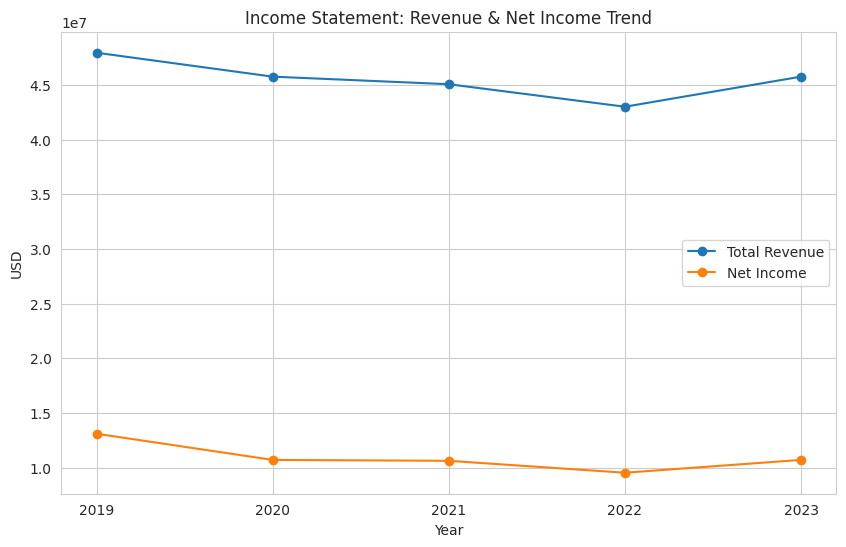

In [67]:
plt.figure(figsize=(10,6))  # grafik boyutu

plt.plot(income['Year'], income['Total Revenue'], marker='o', label='Total Revenue')
plt.plot(income['Year'], income['Net Income'], marker='o', label='Net Income')

plt.title('Income Statement: Revenue & Net Income Trend')
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend()
plt.show()

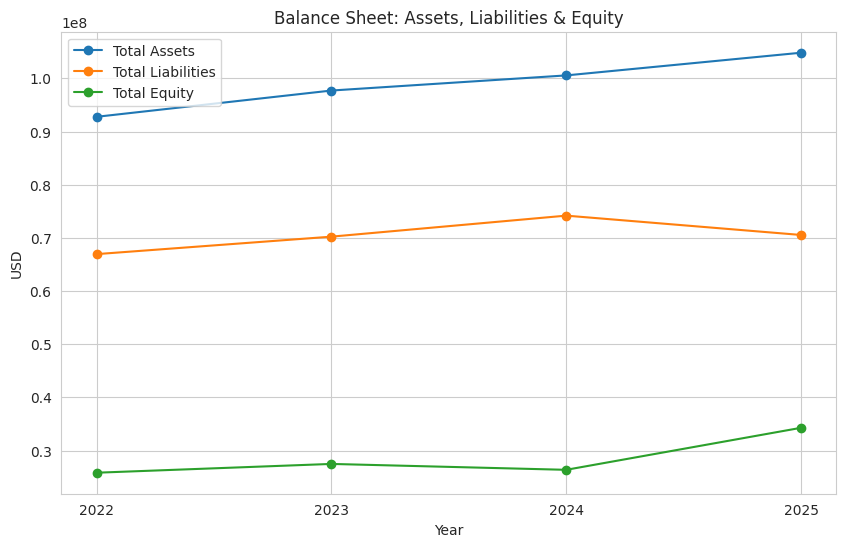

In [68]:
# Year sütununu string yapalım (grafik için)
balance['Year'] = balance['Year'].astype(str)

plt.figure(figsize=(10,6))

plt.plot(balance['Year'], balance['Total Assets'], marker='o', label='Total Assets')
plt.plot(balance['Year'], balance['Total Liabilities'], marker='o', label='Total Liabilities')
plt.plot(balance['Year'], balance['Total Equity'], marker='o', label='Total Equity')

plt.title('Balance Sheet: Assets, Liabilities & Equity')
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend()
plt.show()

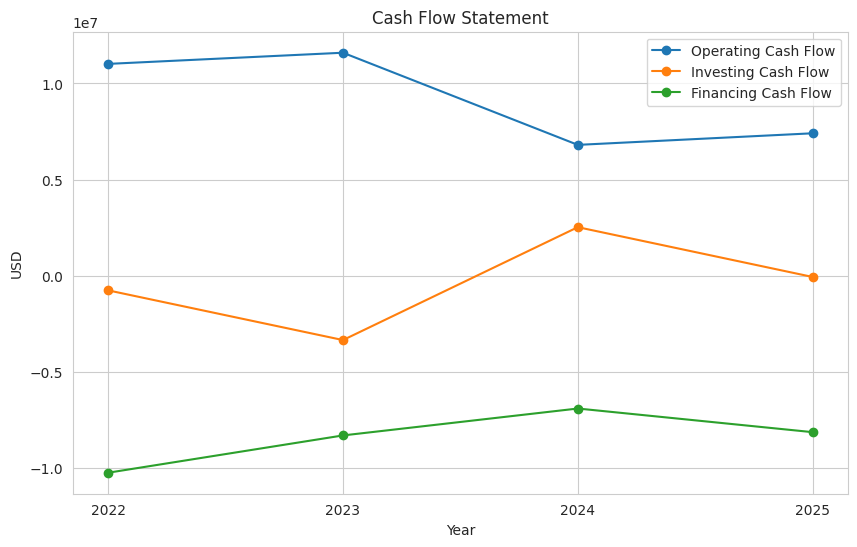

In [69]:
# Year sütununu string yapalım
cashflow['Year'] = cashflow['Year'].astype(str)

plt.figure(figsize=(10,6))

plt.plot(cashflow['Year'], cashflow['Operating Cash Flow'], marker='o', label='Operating Cash Flow')
plt.plot(cashflow['Year'], cashflow['Investing Cash Flow'], marker='o', label='Investing Cash Flow')
plt.plot(cashflow['Year'], cashflow['Financing Cash Flow'], marker='o', label='Financing Cash Flow')

plt.title('Cash Flow Statement')
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend()
plt.show()

In [70]:
income['Profit Margin'] = income['Net Income'] / income['Total Revenue']

print(income[['Year','Total Revenue','Net Income','Profit Margin']])

   Year  Total Revenue  Net Income  Profit Margin
0  2019       47941000    13107000       0.273399
1  2020       45754000    10714000       0.234165
2  2021       45061000    10631000       0.235925
3  2022       43004000     9542000       0.221886
4  2023       45754000    10714000       0.234165


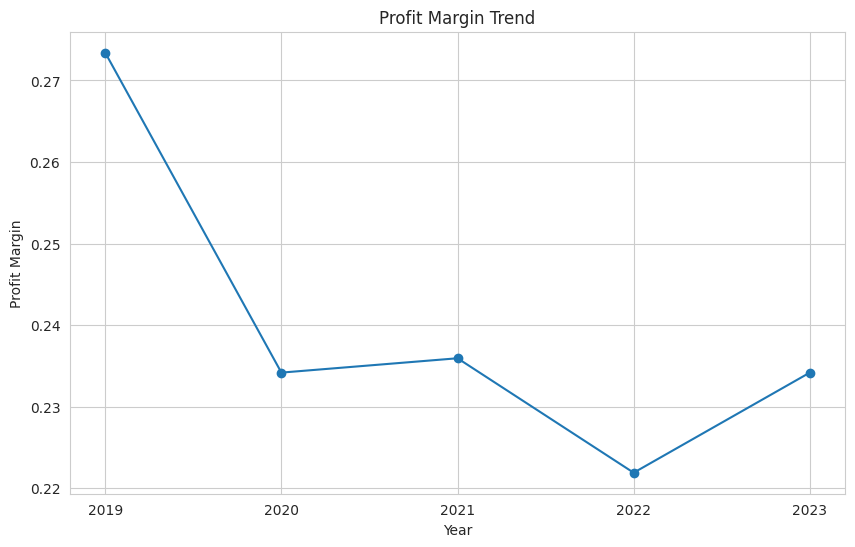

In [71]:
plt.figure(figsize=(10,6))

plt.plot(income['Year'], income['Profit Margin'], marker='o')

plt.title('Profit Margin Trend')
plt.xlabel('Year')
plt.ylabel('Profit Margin')

plt.show()

In [72]:
balance['Debt Ratio'] = balance['Total Liabilities'] / balance['Total Assets']

print(balance[['Year','Debt Ratio']])

   Year  Debt Ratio
0  2022    0.721592
1  2023    0.718739
2  2024    0.737720
3  2025    0.672998


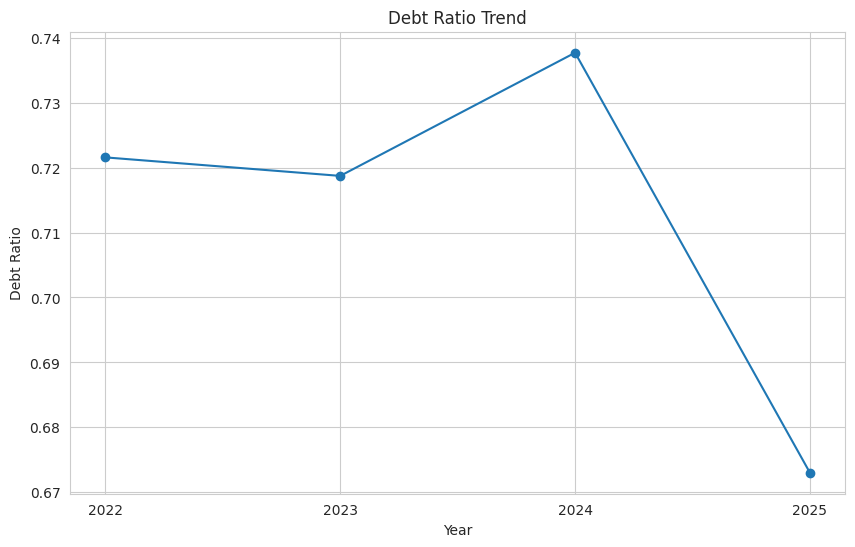

In [73]:
plt.figure(figsize=(10,6))

plt.plot(balance['Year'], balance['Debt Ratio'], marker='o')

plt.title('Debt Ratio Trend')
plt.xlabel('Year')
plt.ylabel('Debt Ratio')

plt.show()

In [74]:
cashflow['Free Cash Flow'] = cashflow['Operating Cash Flow'] - cashflow['Investing Cash Flow']

print(cashflow[['Year','Free Cash Flow']])

   Year  Free Cash Flow
0  2022        11781000
1  2023        14948000
2  2024         4281000
3  2025         7475000


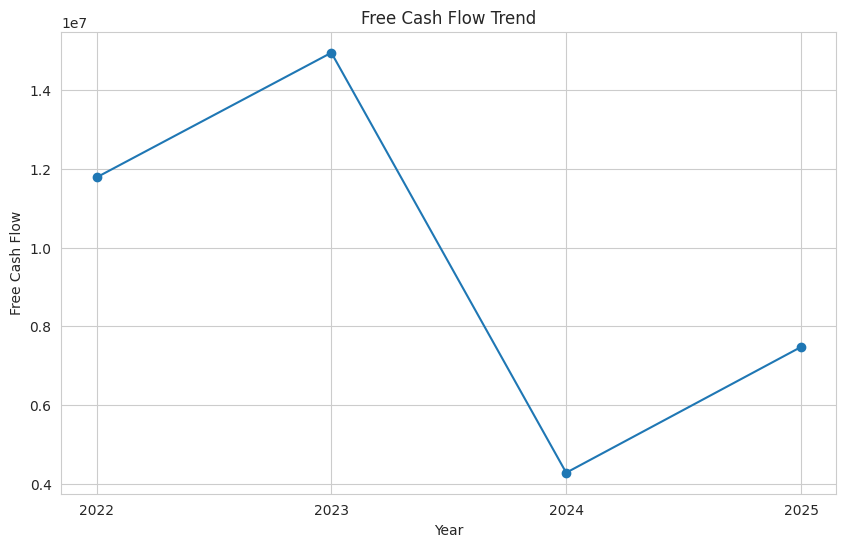

In [75]:
plt.figure(figsize=(10,6))

plt.plot(cashflow['Year'], cashflow['Free Cash Flow'], marker='o')

plt.title('Free Cash Flow Trend')
plt.xlabel('Year')
plt.ylabel('Free Cash Flow')

plt.show()

In [76]:
income[['Total Revenue','Net Income']].corr()

,Total Revenue,Net Income
Total Revenue,1.000000,0.950747
Net Income,0.950747,1.000000


In [77]:
# Financial Ratios hesaplama

income['Profit Margin'] = income['Net Income'] / income['Total Revenue']

balance['Debt Ratio'] = balance['Total Liabilities'] / balance['Total Assets']

cashflow['Free Cash Flow'] = cashflow['Operating Cash Flow'] - cashflow['Investing Cash Flow']

In [78]:
financial_summary = pd.DataFrame()

financial_summary['Year'] = income['Year']
financial_summary['Revenue'] = income['Total Revenue']
financial_summary['Net Income'] = income['Net Income']
financial_summary['Profit Margin'] = income['Profit Margin']
financial_summary['Debt Ratio'] = balance['Debt Ratio']
financial_summary['Free Cash Flow'] = cashflow['Free Cash Flow']

print(financial_summary)

   Year   Revenue  Net Income  Profit Margin  Debt Ratio  Free Cash Flow
0  2019  47941000    13107000       0.273399    0.721592      11781000.0
1  2020  45754000    10714000       0.234165    0.718739      14948000.0
2  2021  45061000    10631000       0.235925    0.737720       4281000.0
3  2022  43004000     9542000       0.221886    0.672998       7475000.0
4  2023  45754000    10714000       0.234165         NaN             NaN


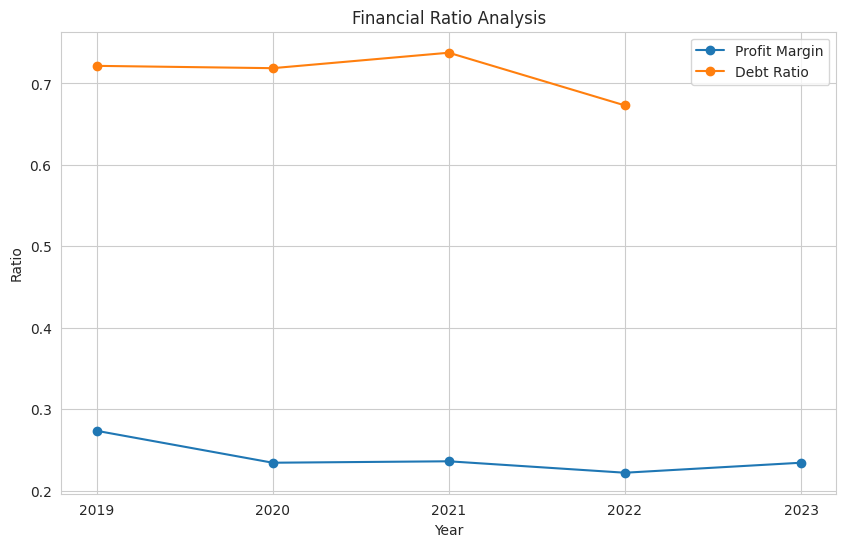

In [79]:
plt.figure(figsize=(10,6))

plt.plot(financial_summary['Year'], financial_summary['Profit Margin'], marker='o', label='Profit Margin')
plt.plot(financial_summary['Year'], financial_summary['Debt Ratio'], marker='o', label='Debt Ratio')

plt.title('Financial Ratio Analysis')
plt.xlabel('Year')
plt.ylabel('Ratio')

plt.legend()
plt.show()

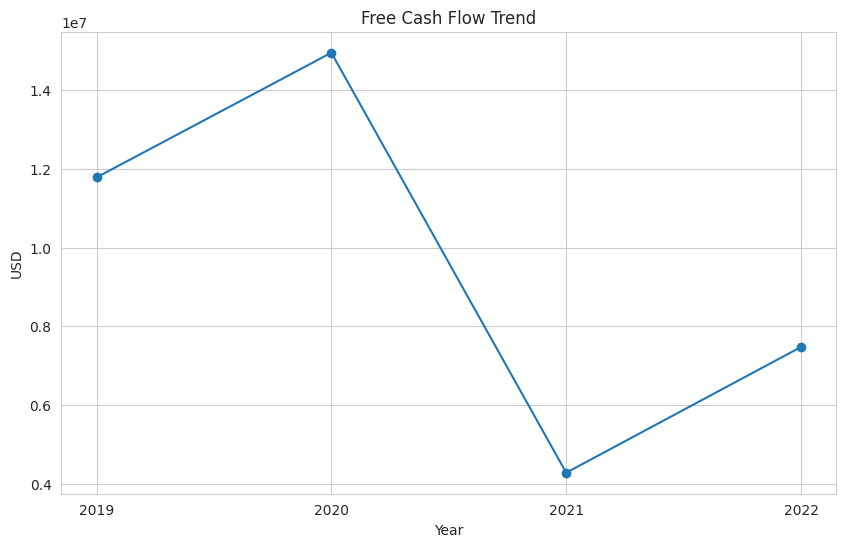

In [80]:
plt.figure(figsize=(10,6))

plt.plot(financial_summary['Year'], financial_summary['Free Cash Flow'], marker='o')

plt.title('Free Cash Flow Trend')
plt.xlabel('Year')
plt.ylabel('USD')

plt.show()

In [81]:
correlation = financial_summary.drop(columns=['Year']).corr()

print(correlation)

                 Revenue  Net Income  Profit Margin  Debt Ratio  \
Revenue         1.000000    0.950747       0.908112    0.656081   
Net Income      0.950747    1.000000       0.993115    0.523666   
Profit Margin   0.908112    0.993115       1.000000    0.473248   
Debt Ratio      0.656081    0.523666       0.473248    1.000000   
Free Cash Flow  0.499537    0.383620       0.324209    0.007587   

                Free Cash Flow  
Revenue               0.499537  
Net Income            0.383620  
Profit Margin         0.324209  
Debt Ratio            0.007587  
Free Cash Flow        1.000000  


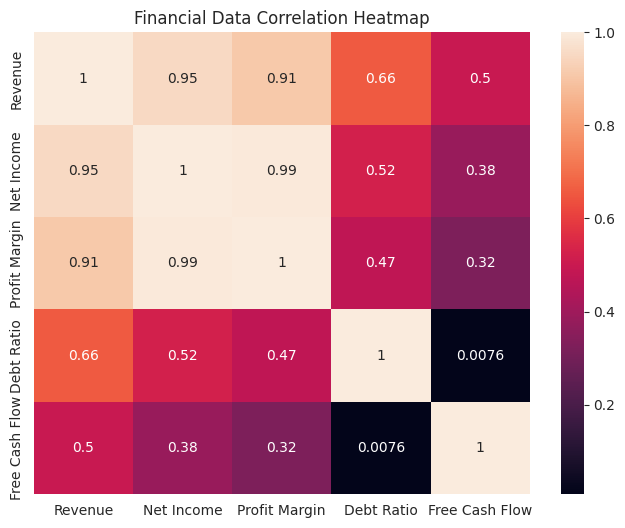

In [82]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True)

plt.title('Financial Data Correlation Heatmap')

plt.show()

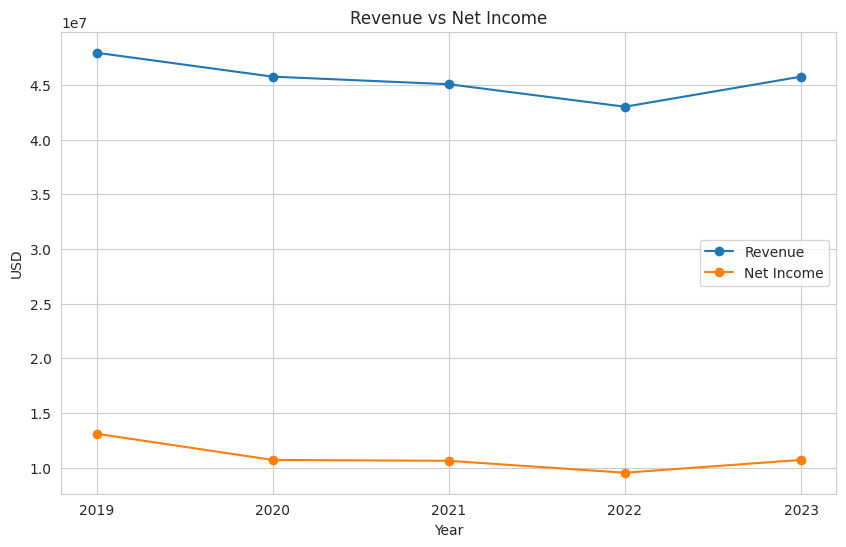

In [83]:
plt.figure(figsize=(10,6))

plt.plot(financial_summary['Year'], financial_summary['Revenue'], marker='o', label='Revenue')
plt.plot(financial_summary['Year'], financial_summary['Net Income'], marker='o', label='Net Income')

plt.title('Revenue vs Net Income')
plt.xlabel('Year')
plt.ylabel('USD')

plt.legend()

plt.savefig('revenue_net_income.png')

plt.show()

In [84]:
# Missing values kontrolü
print(income.isnull().sum())
print(balance.isnull().sum())
print(cashflow.isnull().sum())

# Veri tipleri
print(income.dtypes)
print(balance.dtypes)
print(cashflow.dtypes)

Year                          0
Total Revenue                 0
Cost of Revenue               0
Gross Profit                  0
Operating Expense             0
Operating Income              0
Net Non Operating Interest    0
Other Income Expense          0
Pretax Income                 0
Tax Provision                 0
Net Income                    0
Profit Margin                 0
dtype: int64
Year                 0
Total Assets         0
Total Liabilities    0
Total Equity         0
Total Debt           0
Net Debt             0
Working Capital      0
Debt Ratio           0
dtype: int64
Year                   0
Operating Cash Flow    0
Investing Cash Flow    0
Financing Cash Flow    0
End Cash Position      0
CapEx                  0
Free Cash Flow         0
dtype: int64
Year                           object
Total Revenue                   int64
Cost of Revenue                 int64
Gross Profit                    int64
Operating Expense               int64
Operating Income            

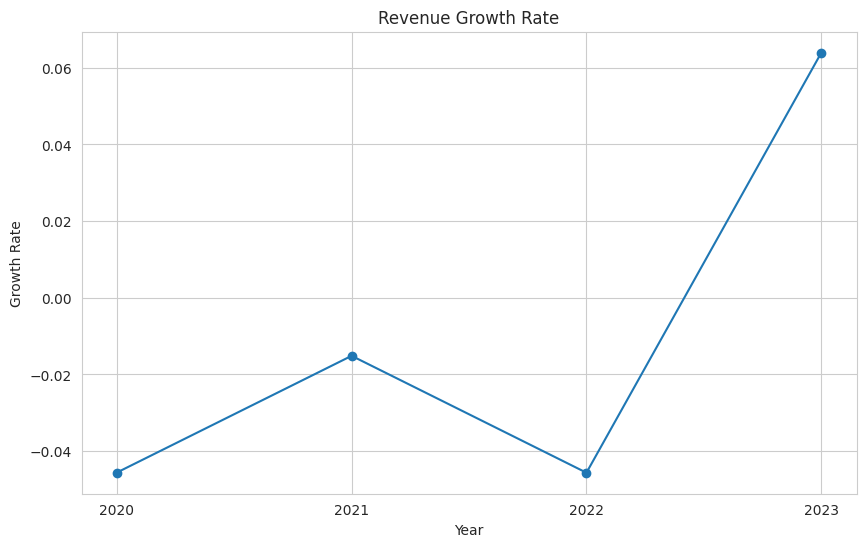

In [85]:
income['Revenue Growth'] = income['Total Revenue'].pct_change()

plt.figure(figsize=(10,6))
plt.plot(income['Year'], income['Revenue Growth'], marker='o')
plt.title('Revenue Growth Rate')
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.show()

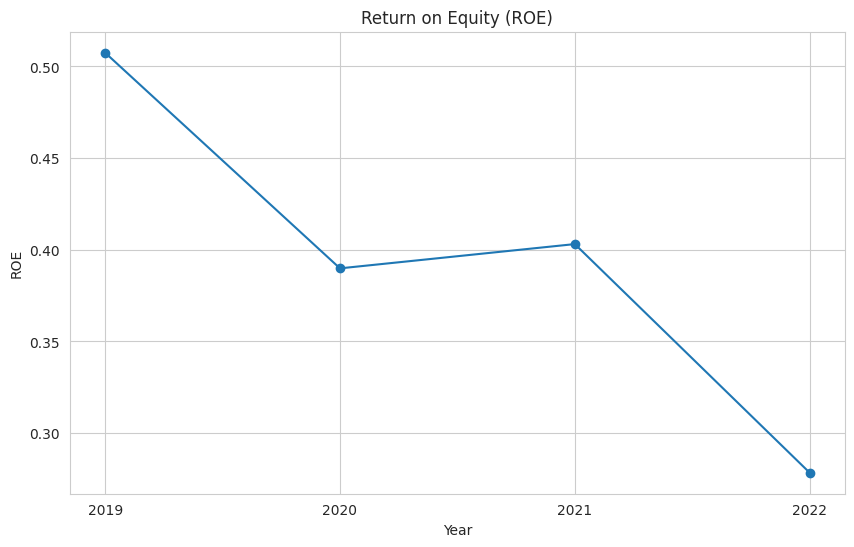

In [86]:
financial_summary['ROE'] = financial_summary['Net Income'] / balance['Total Equity']

plt.figure(figsize=(10,6))
plt.plot(financial_summary['Year'], financial_summary['ROE'], marker='o')

plt.title('Return on Equity (ROE)')
plt.xlabel('Year')
plt.ylabel('ROE')

plt.show()

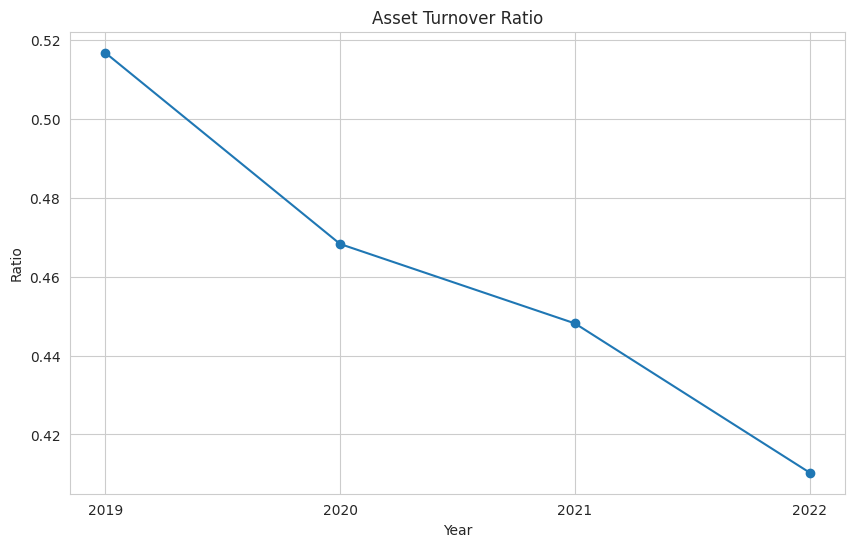

In [87]:
financial_summary['Asset Turnover'] = financial_summary['Revenue'] / balance['Total Assets']

plt.figure(figsize=(10,6))
plt.plot(financial_summary['Year'], financial_summary['Asset Turnover'], marker='o')

plt.title('Asset Turnover Ratio')
plt.xlabel('Year')
plt.ylabel('Ratio')

plt.show()

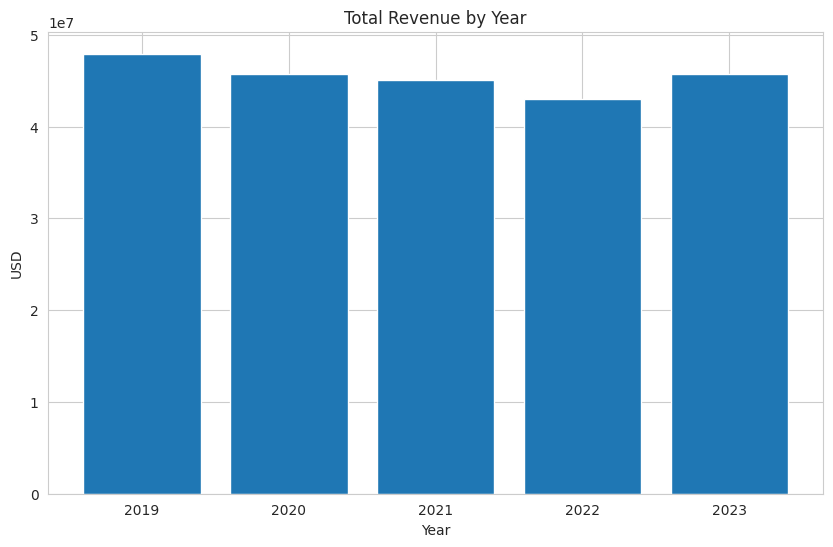

In [88]:
plt.figure(figsize=(10,6))

plt.bar(financial_summary['Year'], financial_summary['Revenue'])

plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('USD')

plt.show()

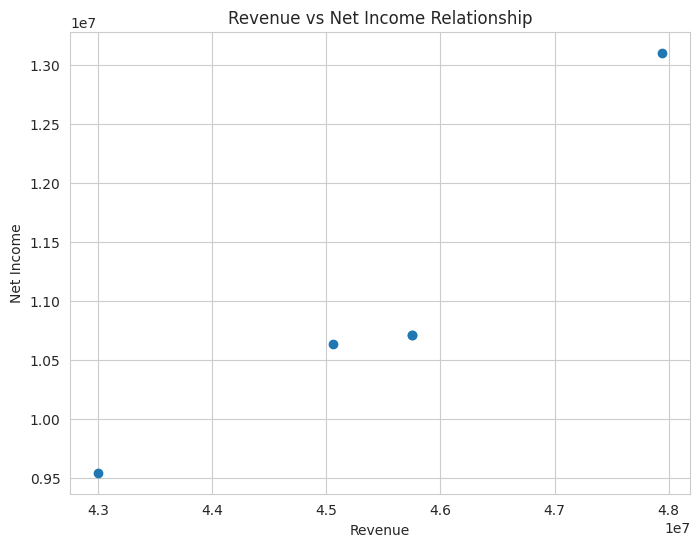

In [89]:
plt.figure(figsize=(8,6))

plt.scatter(financial_summary['Revenue'], financial_summary['Net Income'])

plt.xlabel('Revenue')
plt.ylabel('Net Income')

plt.title('Revenue vs Net Income Relationship')

plt.show()

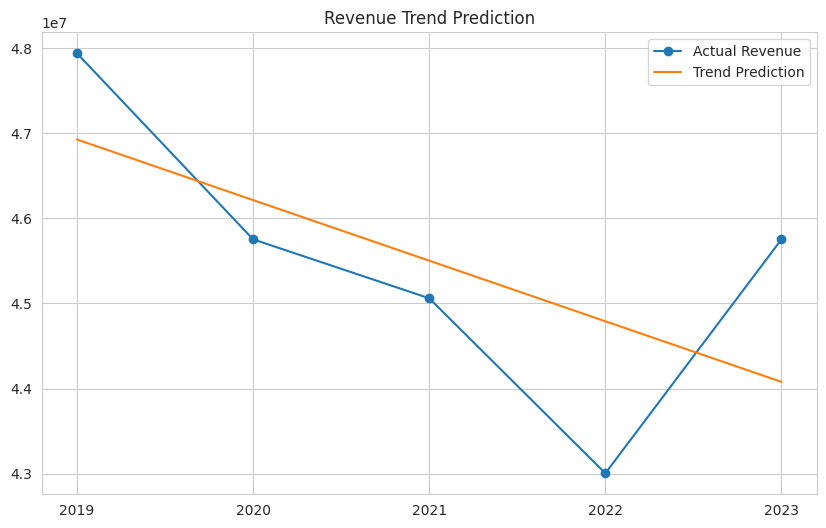

In [90]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.arange(len(income)).reshape(-1,1)
y = income['Total Revenue']

model = LinearRegression()
model.fit(X,y)

predicted = model.predict(X)

plt.figure(figsize=(10,6))
plt.plot(income['Year'], y, marker='o', label='Actual Revenue')
plt.plot(income['Year'], predicted, label='Trend Prediction')

plt.legend()
plt.title('Revenue Trend Prediction')

plt.show()

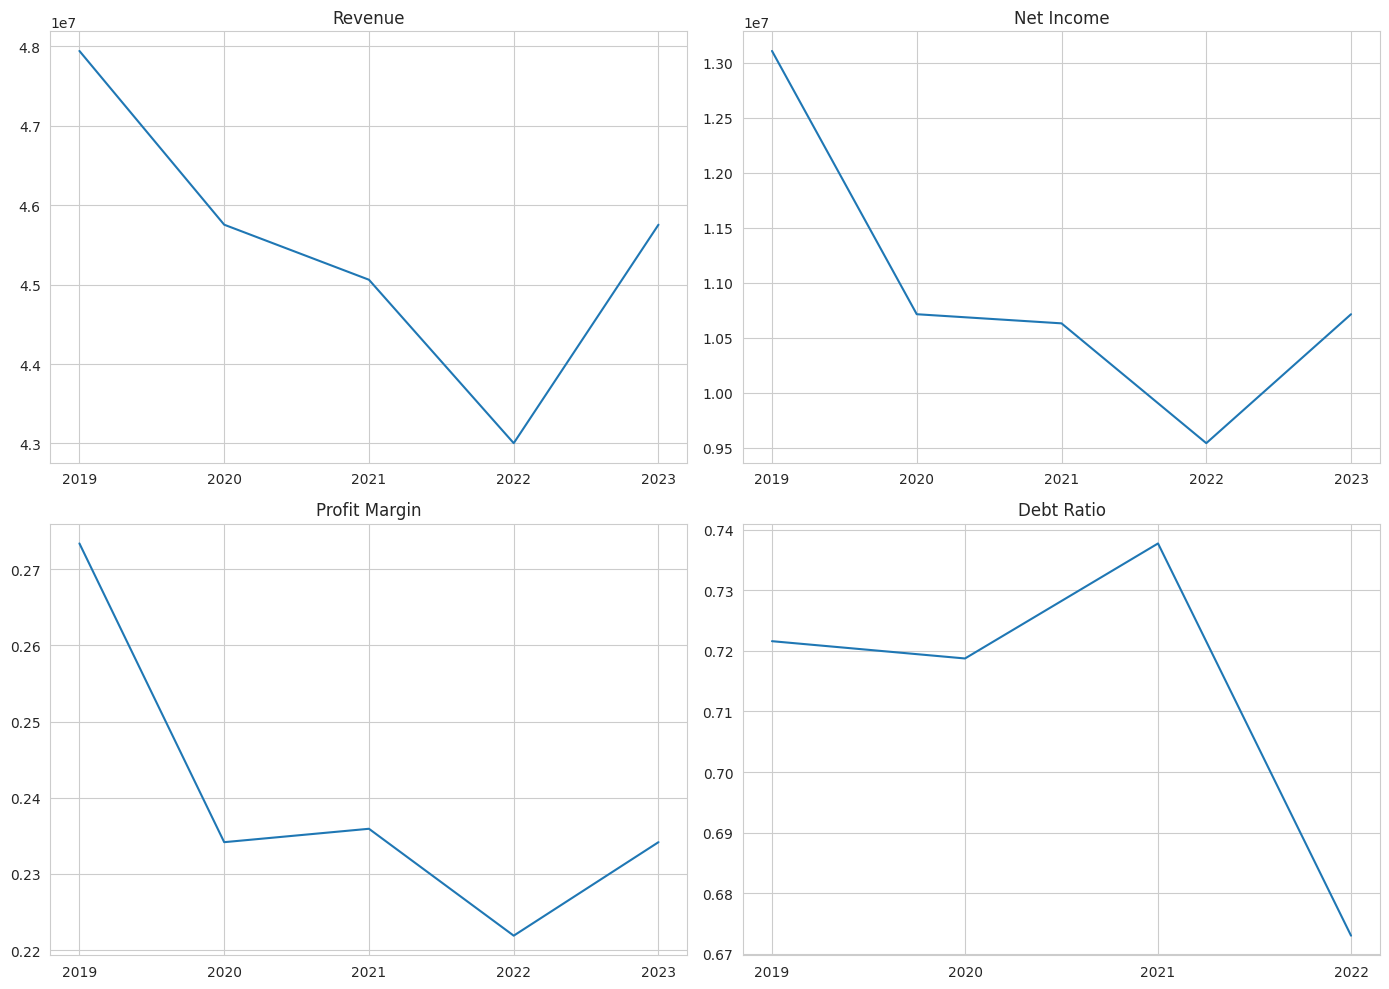

In [91]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

axes[0,0].plot(financial_summary['Year'], financial_summary['Revenue'])
axes[0,0].set_title('Revenue')

axes[0,1].plot(financial_summary['Year'], financial_summary['Net Income'])
axes[0,1].set_title('Net Income')

axes[1,0].plot(financial_summary['Year'], financial_summary['Profit Margin'])
axes[1,0].set_title('Profit Margin')

axes[1,1].plot(financial_summary['Year'], financial_summary['Debt Ratio'])
axes[1,1].set_title('Debt Ratio')

plt.tight_layout()
plt.show()

In [92]:
financial_summary.to_csv("financial_analysis_summary.csv")

In [93]:
# --- CLEAN MERGED FINANCIAL DATASET ---

income['Year'] = income['Year'].astype(int)
balance['Year'] = balance['Year'].astype(int)
cashflow['Year'] = cashflow['Year'].astype(int)

financial_data = income.merge(balance, on="Year").merge(cashflow, on="Year")

print(financial_data.head())

   Year  Total Revenue  Cost of Revenue  Gross Profit  Operating Expense  \
0  2022       43004000         18000000      25004000           12962000   
1  2023       45754000         18520000      27234000           14136000   

   Operating Income  Net Non Operating Interest  Other Income Expense  \
0          12042000                     -433000                 77000   
1          13098000                     -620000                474000   

   Pretax Income  Tax Provision  ...  Total Debt  Net Debt  Working Capital  \
0       11686000        2115000  ...    39149000  29630000          2867000   
1       12952000        2249000  ...    42064000  32698000          3161000   

   Debt Ratio  Operating Cash Flow  Investing Cash Flow  Financing Cash Flow  \
0    0.721592             11018000              -763000            -10250000   
1    0.718739             11599000             -3349000             -8310000   

   End Cash Position    CapEx  Free Cash Flow  
0            9825000 -14

In [94]:
# --- WARREN BUFFETT STYLE METRICS ---

financial_data['Profit Margin'] = financial_data['Net Income'] / financial_data['Total Revenue']
financial_data['ROE'] = financial_data['Net Income'] / financial_data['Total Equity']
financial_data['Debt Ratio'] = financial_data['Total Liabilities'] / financial_data['Total Assets']
financial_data['Free Cash Flow'] = financial_data['Operating Cash Flow'] - financial_data['Investing Cash Flow']

print("Average Profit Margin:", financial_data['Profit Margin'].mean())
print("Average ROE:", financial_data['ROE'].mean())
print("Average Debt Ratio:", financial_data['Debt Ratio'].mean())

# Buffett-style evaluation

if financial_data['ROE'].mean() > 0.15:
    print("Strong ROE (Buffett likes this)")

if financial_data['Debt Ratio'].mean() < 0.6:
    print("Healthy debt level")

if financial_data['Profit Margin'].mean() > 0.2:
    print("Strong pricing power")

Average Profit Margin: 0.22802582751699998
Average ROE: 0.3796780880804479
Average Debt Ratio: 0.7201655139518928
Strong ROE (Buffett likes this)
Strong pricing power


In [95]:
# --- DISCOUNTED CASH FLOW MODEL ---

latest_fcf = financial_data['Free Cash Flow'].iloc[-1]

growth_rate = 0.05
discount_rate = 0.09
terminal_growth = 0.025
years = 5

future_values = []

for i in range(1, years+1):
    fcf = latest_fcf * (1 + growth_rate)**i
    discounted = fcf / (1 + discount_rate)**i
    future_values.append(discounted)

terminal_value = (future_values[-1] * (1 + terminal_growth)) / (discount_rate - terminal_growth)

terminal_discounted = terminal_value / ((1 + discount_rate)**years)

enterprise_value = sum(future_values) + terminal_discounted

print("Estimated Enterprise Value:", enterprise_value)

Estimated Enterprise Value: 193982817.4989742


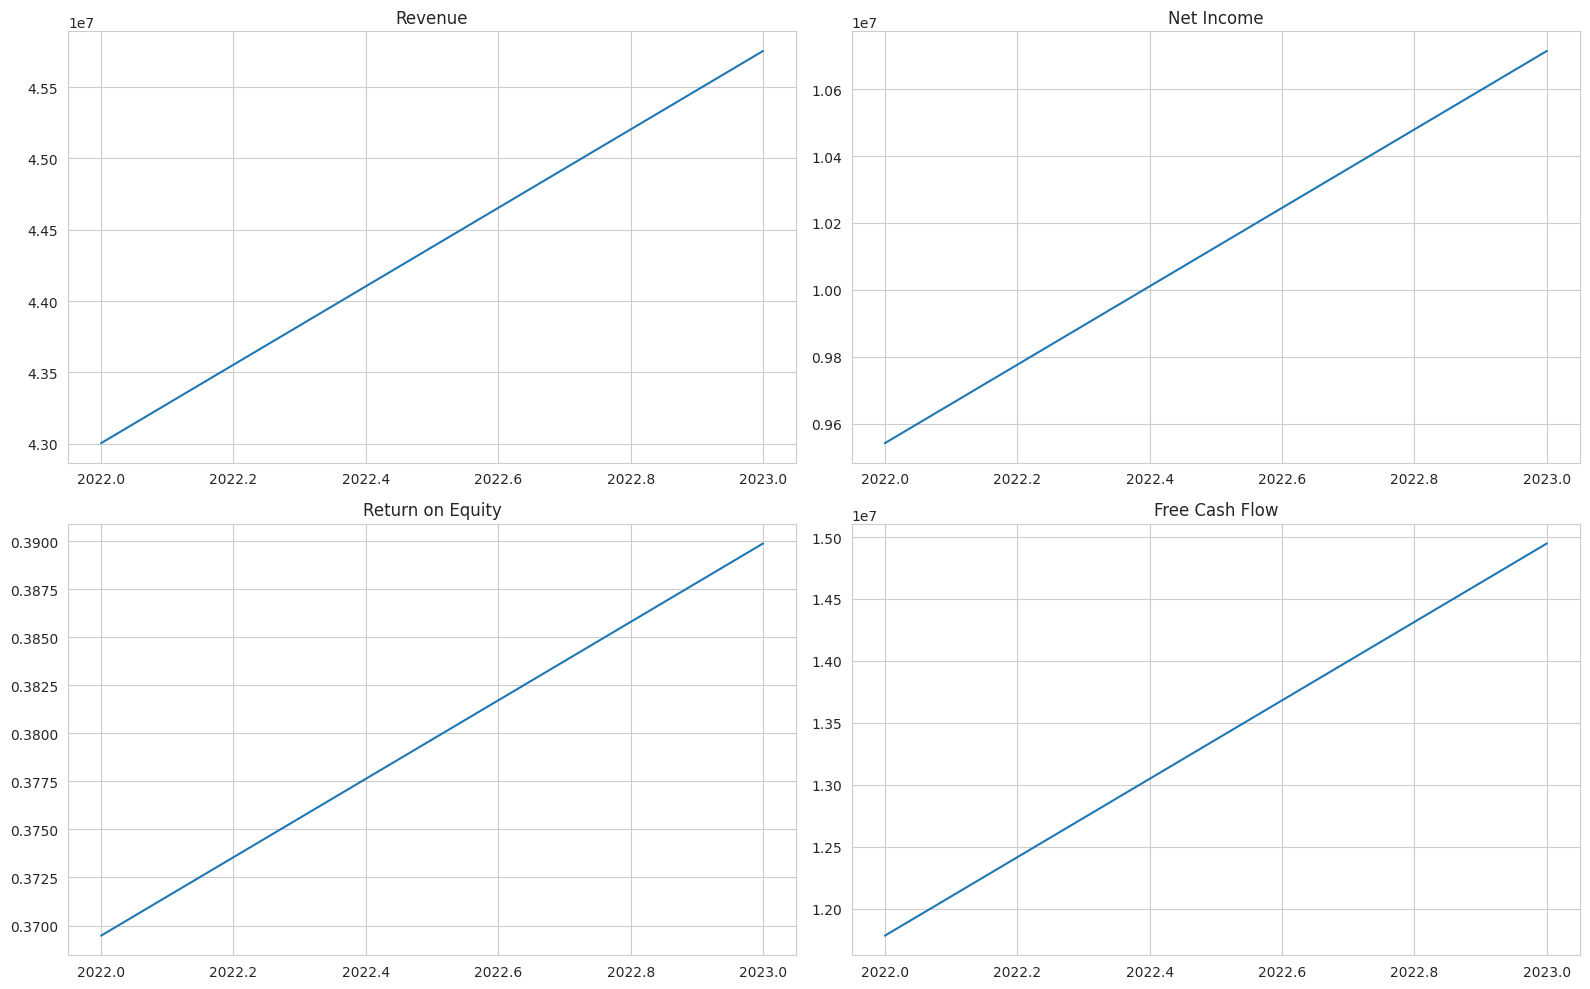

In [96]:
# --- PROFESSIONAL FINANCIAL DASHBOARD ---

fig, axes = plt.subplots(2,2, figsize=(16,10))

axes[0,0].plot(financial_data['Year'], financial_data['Total Revenue'])
axes[0,0].set_title("Revenue")

axes[0,1].plot(financial_data['Year'], financial_data['Net Income'])
axes[0,1].set_title("Net Income")

axes[1,0].plot(financial_data['Year'], financial_data['ROE'])
axes[1,0].set_title("Return on Equity")

axes[1,1].plot(financial_data['Year'], financial_data['Free Cash Flow'])
axes[1,1].set_title("Free Cash Flow")

plt.tight_layout()
plt.show()

Future Revenue Forecast:
[48504000.         51254000.         54004000.         56754000.
 59503999.99999999]


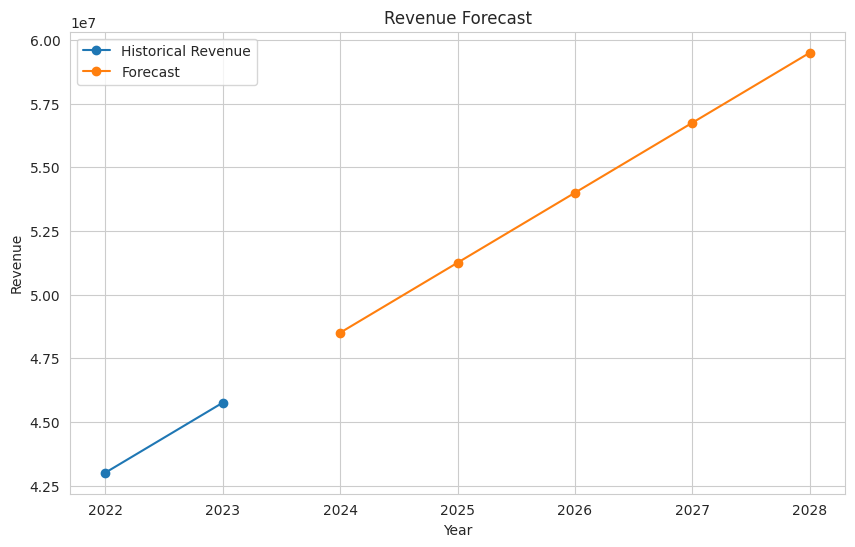

In [97]:
# --- MACHINE LEARNING REVENUE FORECAST ---

from sklearn.linear_model import LinearRegression
import numpy as np

years_numeric = np.arange(len(financial_data)).reshape(-1,1)
revenue = financial_data['Total Revenue']

model = LinearRegression()
model.fit(years_numeric, revenue)

future_years = np.arange(len(financial_data), len(financial_data)+5).reshape(-1,1)

future_predictions = model.predict(future_years)

print("Future Revenue Forecast:")
print(future_predictions)

plt.figure(figsize=(10,6))

plt.plot(financial_data['Year'], revenue, marker='o', label="Historical Revenue")

future_year_labels = np.arange(financial_data['Year'].max()+1, financial_data['Year'].max()+6)

plt.plot(future_year_labels, future_predictions, marker='o', label="Forecast")

plt.legend()
plt.title("Revenue Forecast")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

In [98]:
# --- INTERACTIVE FINANCIAL VISUALIZATION ---

import plotly.express as px

fig = px.line(
    financial_data,
    x="Year",
    y=["Total Revenue","Net Income"],
    title="Interactive Revenue vs Net Income"
)

fig.show()

/tmp/ipykernel_11036/3154707010.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  5 of 5 completed


Annual Return: 0.11411323746662123
Annual Volatility: 0.19243737216469778


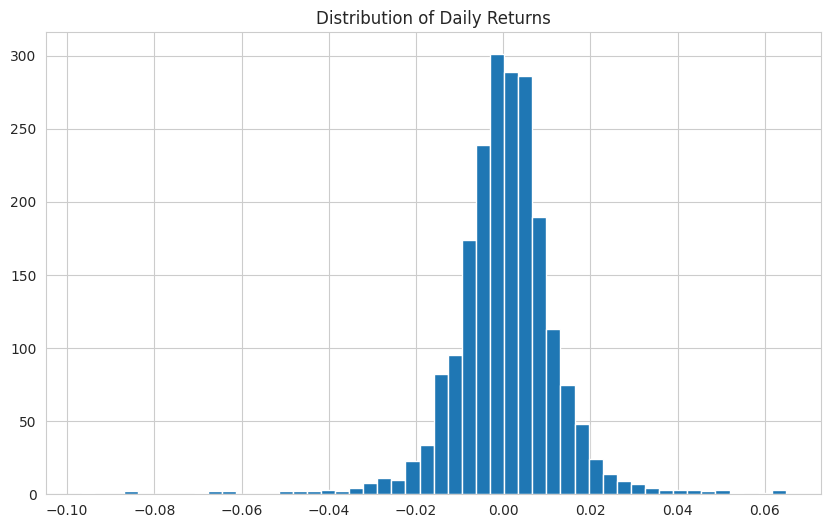

In [99]:
# --- STOCK RISK ANALYSIS ---

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["KO","AAPL","MSFT","TSLA","AMZN"]
data = yf.download(tickers, start="2018-01-01")["Close"]

# 'stock' değişkeni tanımlanmadığı için 'data' DataFrame'inden bir hisse senedi seçmeliyiz.
# Örneğin, 'KO' (Coca-Cola) hissesini seçelim.
returns = data['KO'].pct_change().dropna()

annual_return = returns.mean() * 252
annual_volatility = returns.std() * (252 ** 0.5)

print("Annual Return:", annual_return)
print("Annual Volatility:", annual_volatility)

plt.figure(figsize=(10,6))

plt.hist(returns, bins=50)

plt.title("Distribution of Daily Returns")

plt.show()

In [100]:
# --- AUTOMATED FINANCIAL SUMMARY ---

print("----- FINANCIAL REPORT -----")

print("Average Revenue:", financial_data['Total Revenue'].mean())

print("Average Net Income:", financial_data['Net Income'].mean())

print("Average Profit Margin:", financial_data['Profit Margin'].mean())

print("Average ROE:", financial_data['ROE'].mean())

print("Average Free Cash Flow:", financial_data['Free Cash Flow'].mean())

print("Debt Ratio:", financial_data['Debt Ratio'].mean())

if financial_data['ROE'].mean() > 0.15:
    print("Company shows strong profitability.")

if financial_data['Free Cash Flow'].mean() > 0:
    print("Company generates healthy free cash flow.")

if financial_data['Debt Ratio'].mean() < 0.6:
    print("Debt levels appear manageable.")

----- FINANCIAL REPORT -----
Average Revenue: 44379000.0
Average Net Income: 10128000.0
Average Profit Margin: 0.22802582751699998
Average ROE: 0.3796780880804479
Average Free Cash Flow: 13364500.0
Debt Ratio: 0.7201655139518928
Company shows strong profitability.
Company generates healthy free cash flow.


In [101]:
# --- DOWNLOAD MULTIPLE STOCK DATA ---

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["KO","AAPL","MSFT","TSLA","AMZN"]

data = yf.download(tickers, start="2018-01-01")["Close"]

print(data.head())

/tmp/ipykernel_11036/1911334845.py:10: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN         KO       MSFT       TSLA
Date                                                             
2018-01-02  40.304165  59.450500  35.250343  78.870361  21.368668
2018-01-03  40.297173  60.209999  35.172939  79.237411  21.150000
2018-01-04  40.484333  60.479500  35.668346  79.934807  20.974667
2018-01-05  40.945263  61.457001  35.660606  80.925873  21.105333
2018-01-08  40.793179  62.343498  35.606415  81.008438  22.427334


In [102]:
# --- CALCULATE RETURNS ---

returns = data.pct_change().dropna()

print(returns.head())

Ticker          AAPL      AMZN        KO      MSFT      TSLA
Date                                                        
2018-01-03 -0.000173  0.012775 -0.002196  0.004654 -0.010233
2018-01-04  0.004645  0.004476  0.014085  0.008801 -0.008290
2018-01-05  0.011385  0.016163 -0.000217  0.012398  0.006230
2018-01-08 -0.003714  0.014425 -0.001520  0.001020  0.062638
2018-01-09 -0.000114  0.004676  0.005000 -0.000679 -0.008085


In [103]:
# --- RISK & RETURN ANALYSIS ---

annual_returns = returns.mean() * 252
volatility = returns.std() * (252 ** 0.5)

summary = pd.DataFrame()

summary["Annual Return"] = annual_returns
summary["Volatility"] = volatility

print(summary)

        Annual Return  Volatility
Ticker                           
AAPL         0.273146    0.306053
AMZN         0.227442    0.343641
KO           0.114113    0.192437
MSFT         0.228354    0.284767
TSLA         0.536172    0.629855


In [104]:
# --- SHARPE RATIO ---

risk_free_rate = 0.02

sharpe = (annual_returns - risk_free_rate) / volatility

summary["Sharpe Ratio"] = sharpe

print(summary.sort_values("Sharpe Ratio", ascending=False))

        Annual Return  Volatility  Sharpe Ratio
Ticker                                         
AAPL         0.273146    0.306053      0.827131
TSLA         0.536172    0.629855      0.819509
MSFT         0.228354    0.284767      0.731666
AMZN         0.227442    0.343641      0.603659
KO           0.114113    0.192437      0.489059


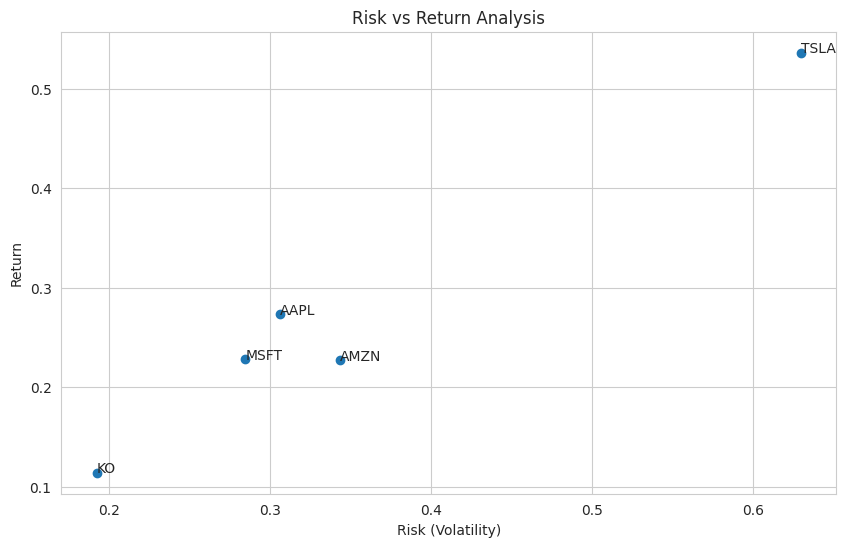

In [105]:
# --- RISK RETURN SCATTER PLOT ---

plt.figure(figsize=(10,6))

plt.scatter(volatility, annual_returns)

for ticker in tickers:
    plt.text(volatility[ticker], annual_returns[ticker], ticker)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")

plt.title("Risk vs Return Analysis")

plt.show()

In [106]:
# --- GET S&P500 TICKERS (ALTERNATIVE METHOD) ---

import requests
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {"User-Agent": "Mozilla/5.0"}

html = requests.get(url, headers=headers).text

tables = pd.read_html(html)

sp500_table = tables[0]

tickers = sp500_table["Symbol"].tolist()

print("Number of companies:", len(tickers))
print(tickers[:20])

Number of companies: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL']


/tmp/ipykernel_11036/3778646292.py:12: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



In [107]:
# --- DOWNLOAD STOCK DATA FOR S&P500 ---

import yfinance as yf

sample_tickers = tickers[:50]

data = yf.download(sample_tickers, start="2018-01-01")["Close"]

print(data.head())

/tmp/ipykernel_11036/716702893.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  50 of 50 completed

Ticker              A       AAPL       ABBV  ABNB        ABT       ACGL  \
Date                                                                      
2018-01-02  63.522778  40.304184  69.343704   NaN  50.822948  27.988113   
2018-01-03  65.139030  40.297150  70.428841   NaN  50.935314  28.013470   
2018-01-04  64.650391  40.484333  70.027214   NaN  50.848862  28.118069   
2018-01-05  65.684067  40.945263  71.246223   NaN  50.995838  28.007132   
2018-01-08  65.825005  40.793182  70.104721   NaN  50.848862  28.010302   

Ticker             ACN        ADBE        ADI        ADM  ...       ARES  \
Date                                                      ...              
2018-01-02  135.558273  177.699997  77.602295  31.407618  ...  14.810273   
2018-01-03  136.183853  181.039993  78.565018  31.164755  ...  14.773609   
2018-01-04  137.796417  183.220001  78.479065  31.689657  ...  14.663631   
2018-01-05  138.933090  185.339996  78.797089  31.478134  ...  14.736957   
2018-01-08  140.04

In [108]:
# --- CALCULATE RETURNS ---

returns = data.pct_change().dropna()

annual_returns = returns.mean() * 252
volatility = returns.std() * (252 ** 0.5)

print(annual_returns.head())

Ticker
A       0.018330
AAPL    0.175788
ABBV    0.196077
ABNB    0.036242
ABT    -0.000596
dtype: float64


In [109]:
# --- SHARPE RATIO ANALYSIS ---

risk_free_rate = 0.02

sharpe = (annual_returns - risk_free_rate) / volatility

summary = pd.DataFrame()

summary["Return"] = annual_returns
summary["Volatility"] = volatility
summary["Sharpe"] = sharpe

print(summary.sort_values("Sharpe", ascending=False).head(10))

          Return  Volatility    Sharpe
Ticker                                
APH     0.337882    0.295828  1.074550
ANET    0.512169    0.462259  1.064705
AFL     0.193949    0.209102  0.831888
APP     0.654301    0.778546  0.814724
ATO     0.169184    0.185061  0.806132
ACGL    0.214759    0.244726  0.795825
ABBV    0.196077    0.226932  0.775902
GOOGL   0.254902    0.308926  0.760383
GOOG    0.252397    0.307166  0.756584
AMAT    0.322481    0.434499  0.696161


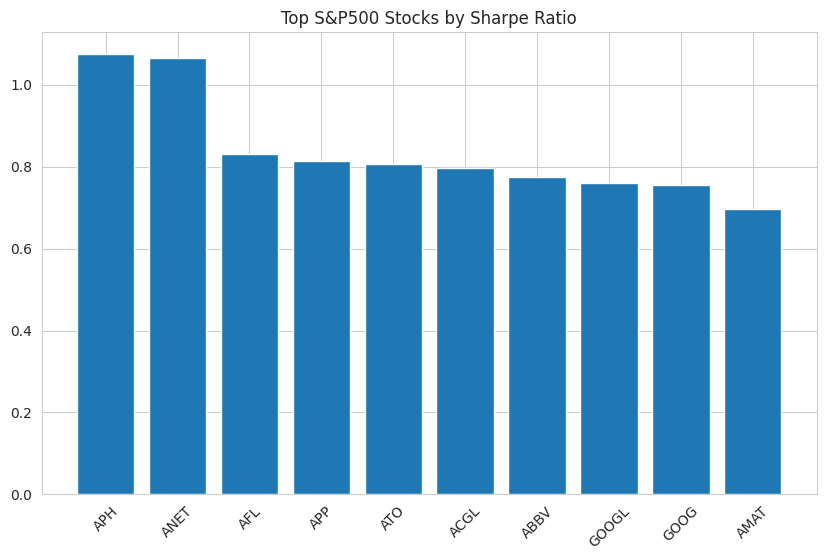

In [110]:
# --- TOP STOCKS VISUALIZATION ---

top_stocks = summary.sort_values("Sharpe", ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.bar(top_stocks.index, top_stocks["Sharpe"])

plt.title("Top S&P500 Stocks by Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()